In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp 
import scipy.io as sio
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV
# set random seed
np.random.seed(42)

## 0. Thermodynamic Model of Ethanol--Toluene Mixture
Consider the ethanol--toluene mixture, which is known to form an azeotrope (with a boiling temperature of about $76.7^\circ\text{C}$), and hence has a nontrivial thermodynamic model. We take the UNIQUAC model as the ground truth, from which the data is collected. The activity coefficients in a UNIQUAC model is given by 
$$
\begin{aligned}
    \ln \gamma_1 =& \ln\frac{\phi_1}{x_1}+ 1-\frac{\phi_1}{x_1} - 5q_1 \left(\ln\frac{\phi_1}{\theta_1}+ 1-\frac{\phi_1}{\theta_1}\right) \\
    &+ q_1\left( 1 - \ln(\theta_1+\theta_2\tau_{21}) - \frac{\theta_1}{\theta_1+\theta_2\tau_{21}} - \frac{\theta_2\tau_{12}}{\theta_1\tau_{12}+\theta_2}\right); \\
    \ln \gamma_2 =& \ln\frac{\phi_2}{x_2}+ 1-\frac{\phi_2}{x_2} - 5q_2 \left(\ln\frac{\phi_2}{\theta_2}+ 1-\frac{\phi_2}{\theta_2}\right) \\
    &+ q_2\left( 1 - \ln(\theta_1\tau_{12}+\theta_2) - \frac{\theta_1\tau_{21}}{\theta_1+\theta_2\tau_{21}} - \frac{\theta_2}{\theta_1\tau_{12}+\theta_2}\right). \\
\end{aligned}
$$
Here $\phi_j = x_jr_j/\sum_i x_ir_i$, $\theta_j=x_jq_j/\sum_i x_iq_i$, and $\tau_{ij} = \exp(-a_{ij}/T)$. The parameters are $r_1=2.1055$, $r_2=3.9228$, $q_1=1.972$, $q_2=2.968$, $a_{12}=-76.1573$ K, and $a_{21} = 438.005$ K. 
The saturated vapor pressures of pure ethanol and toluene are given by Antoine equation: $$\log_{10}\frac{P^\text{sat}}{\text{mmHg}} = A-\frac{B}{T/^\circ\text{C}+C}, $$
where $(A, B, C)$ for ethanol is $(8.11220, 1592.864, 226.184)$ and for toluene is $(6.95087, 1342.31, 219.187)$. These data come from Elliott and Lira \cite{elliott2012introductory}. The vapor is assumed to be an ideal gas mixture. 

In [2]:
# Saturated pressure models
r1, r2 = 2.1055, 3.9228
q1, q2 = 1.972, 2.968
a12, a21 = -76.1573, 438.005
A1, B1, C1 = 8.11220, 1592.864, 226.184
A2, B2, C2 = 6.95087, 1342.31, 219.187
def Psat(T):
    return 10**(A1 - B1/(T + C1)), 10**(A2 - B2/(T + C2))
def boiling_point(P=760):
    return B1/(A1-np.log10(P)) - C1, B2/(A2-np.log10(P)) - C2
def activity(x, T):
    if x == 0:
        x = 1e-6
    elif x == 1:
        x = 1 - 1e-6
    x1, x2 = x, 1-x
    phi1, phi2 = x1*r1/(x1*r1 + x2*r2), x2*r2/(x1*r1 + x2*r2)
    theta1, theta2 = x1*q1/(x1*q1 + x2*q2), x2*q2/(x1*q1 + x2*q2)
    tau12, tau21 = np.exp(-a12/(T+273.15)), np.exp(-a21/(T+273.15))
    lga1 = np.log(phi1/x1) + 1 - phi1/x1 - 5*q1*(np.log(phi1/theta1) + 1 - phi1/theta1) \
        + q1*(1-np.log(theta1+theta2*tau21) - theta1/(theta1+theta2*tau21) - theta2*tau12/(theta1*tau12+theta2))
    lga2 = np.log(phi2/x2) + 1 - phi2/x2 - 5*q2*(np.log(phi2/theta2) + 1 - phi2/theta2) \
        + q2*(1-np.log(theta2+theta1*tau12) - theta2/(theta2+theta1*tau12) - theta1*tau21/(theta2*tau21+theta1))
    return np.exp(lga1), np.exp(lga2)

boiling_points = boiling_point()
print(f"Normal boiling points of ethanol and toluene: {boiling_points[0]:.2f} °C, {boiling_points[1]:.2f} °C")

Normal boiling points of ethanol and toluene: 78.30 °C, 110.61 °C


In [3]:
def solve_T(x, P=760):
    def f(T):
        Psat1, Psat2 = Psat(T)
        gamma1, gamma2 = activity(x, T)
        return x*gamma1*Psat1 + (1-x)*gamma2*Psat2 - P
    T = sp.optimize.fsolve(f, 100)[0]
    y = x*activity(x, T)[0]*Psat(T)[0]/P
    return T, y

# Generate random sample
x_sample = np.random.rand(50)
T_sample, y_sample = [], []
for x in x_sample:
    T, y = solve_T(x)
    T_sample.append(T)
    y_sample.append(y)
T_sample = np.array(T_sample)
y_sample = np.array(y_sample)
sio.savemat('ethanol_toluene_data.mat', {'x': x_sample, 'T': T_sample, 'y': y_sample})

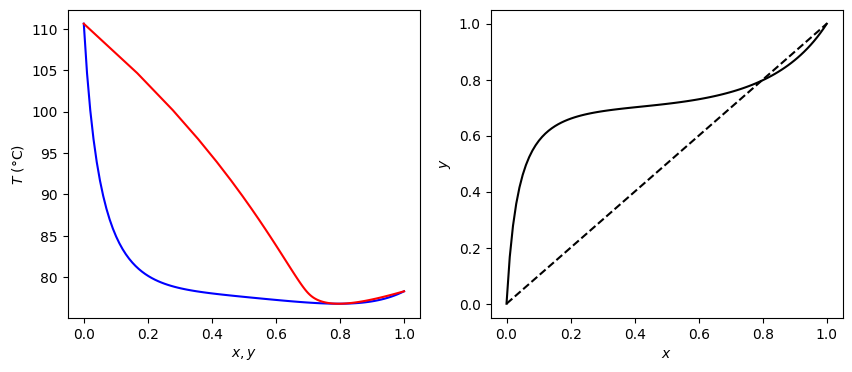

In [4]:
# Make a T-x-y diagram at P=760 mmHg
x_values = np.linspace(0, 1, 100)
T_values = []
y_values = []
for x in x_values:
    T, y = solve_T(x, P=760)
    T_values.append(T)
    y_values.append(y)
# create 1*2 subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(x_values, T_values, color='blue')
axes[0].plot(y_values, T_values, color='red')
axes[0].set_xlabel(r'$x, y$'), axes[0].set_ylabel(r'$T$ (°C)')
# Make a x-y diagram at P=760 mmHg
axes[1].plot(x_values, y_values, color='black')
axes[1].plot(x_values, x_values, color='black', linestyle='--')
axes[1].set_xlabel(r'$x$'), axes[1].set_ylabel(r'$y$')
plt.show()

## 1. Hybrid Modeling by Regularization near a Reference Model

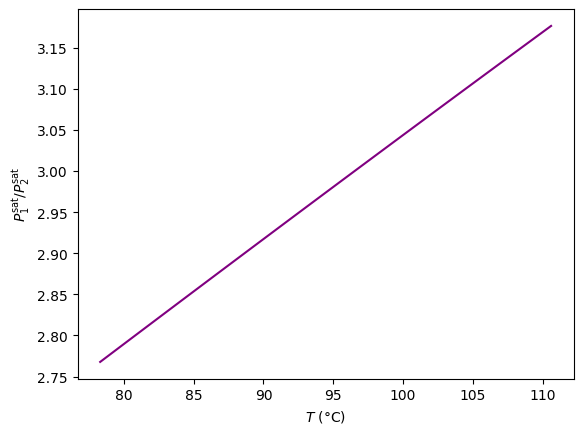

2.9731989665273058


In [5]:
T_range = np.linspace(78.30, 110.61, 100)
rel_volality = [Psat(T)[0]/Psat(T)[1] for T in T_range]
plt.plot(T_range, rel_volality, color='purple')
plt.xlabel(r'$T$ (°C)'), plt.ylabel(r'$P^\mathrm{sat}_1/P^\mathrm{sat}_2$')
plt.show()
print(np.mean(rel_volality))

RMSE_val: 0.0131, RMSE_train: 0.0012, alpha: 1.0e-03
RMSE_val: 0.0166, RMSE_train: 0.0023, alpha: 1.0e-02
RMSE_val: 0.0202, RMSE_train: 0.0046, alpha: 1.0e-01
RMSE_val: 0.0262, RMSE_train: 0.0192, alpha: 1.0e+00
RMSE_val: 0.0848, RMSE_train: 0.0918, alpha: 1.0e+01
RMSE_val: 0.1456, RMSE_train: 0.1620, alpha: 1.0e+02


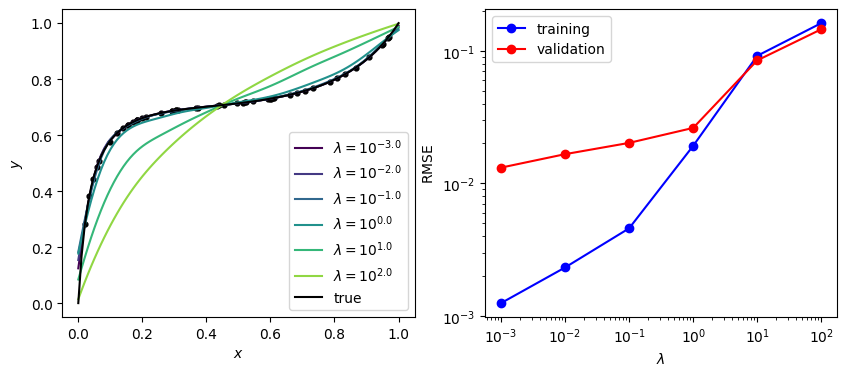

In [6]:
def nominal_model(x):
    alpha = 2.973
    return alpha*x/(alpha*x + 1-x)

eta_sample = y_sample - nominal_model(x_sample)
# perform kernel ridge regression from x_sample to eta_sample
alpha_range = np.logspace(-3, 2, 6)
rmse_train_range = []
rmse_val_range = []
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
cm = plt.get_cmap('viridis')
x_test = np.linspace(0, 1, 100)
for k in range(len(alpha_range)):
    alpha = alpha_range[k]
    krr = KernelRidge(kernel='rbf', alpha=alpha, gamma=100) 
    krr.fit(x_sample.reshape(-1, 1), eta_sample)
    eta_predict = krr.predict(x_sample.reshape(-1, 1))
    rmse_train = np.sqrt(np.mean((eta_predict - eta_sample)**2))
    rmse_train_range.append(rmse_train)
    eta_predict = krr.predict(x_test.reshape(-1, 1))
    eta_true = [solve_T(x)[1] - nominal_model(x) for x in x_test]
    rmse_val = np.sqrt(np.mean((eta_predict - eta_true)**2))
    rmse_val_range.append(rmse_val)
    print(f"RMSE_val: {rmse_val:.4f}, RMSE_train: {rmse_train:.4f}, alpha: {alpha:.1e}")
    ax1.plot(x_test, eta_predict + nominal_model(x_test), color=cm(k/len(alpha_range)), 
             label=r'$\lambda=10^{' + f'{np.log10(alpha):.1f}' + r'}$')
ax1.set_xlabel(r'$x$'), ax1.set_ylabel(r'$y$')
ax1.scatter(x_sample, y_sample, marker='o', c='k', s=12)
ax1.plot(x_test, eta_true + nominal_model(x_test), color='k', label='true')
ax1.legend()
ax2.loglog(alpha_range, rmse_train_range, color='blue', marker='o', markerfacecolor='blue', label='training')
ax2.loglog(alpha_range, rmse_val_range, color='red', marker='o', markerfacecolor='red', label='validation')
ax2.set_xlabel(r'$\lambda$'), ax2.set_ylabel(r'$\mathrm{RMSE}$')
ax2.legend()
plt.show()

## 2. Hybrid Modeling by Regularization near an Interpretable Subspace

Suppose that the user is able to convert the phase diagram data (in the form of $T$--$x$--$y$) to the data of excess molar Gibbs energy, normalized by $RT$: 
$$ \frac{G^\text{ex}}{RT} = x\ln\frac{Py}{P^\text{sat}_1(T)} + (1-x)\ln\frac{P(1-y)}{P^\text{sat}_2(T)} .$$
The user thus decides to find a model that relates $G^\text{ex}/RT$ to $x$ as the argument. The class of interpretable models $\mathcal{M}$ comprises of the two-parameter Margules models: 
$$ G^\text{ex}/RT = \theta_1 x^2(1-x) + \theta_2x(1-x)^2, $$
where $\theta = (\theta_1,\theta_2) \in \Theta=\mathbb{R}^2$. 

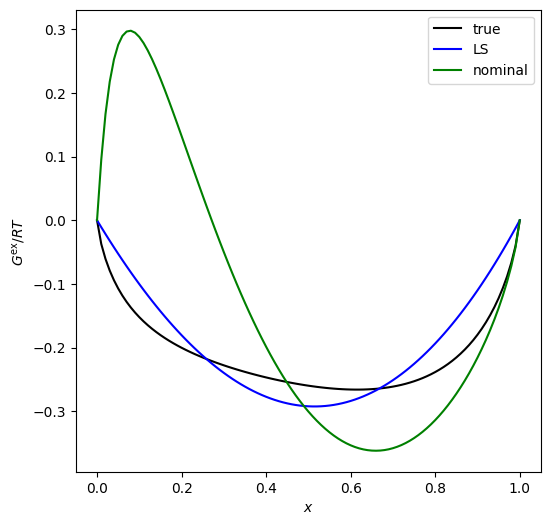

(<matplotlib.legend.Legend at 0x26945059d10>, None)

In [7]:
def excess_gibbs_energy(x, P=760):
    T, y = solve_T(x, P=P)
    P1, P2 = Psat(T)
    if x == 0 or x == 1:
        return 0
    else:
        return x*np.log(P*y/P1) + (1-x)*np.log(P*(1-y)/P2)
def Margules_model(x, theta):
    return theta[0]*x**2*(1-x) + theta[1]*x*(1-x)**2

g_sample = np.array([excess_gibbs_energy(x) for x in x_sample])

# Simple LS Regression for a Margules_model
Phi = np.vstack((x_sample**2*(1-x_sample), (1-x_sample)**2*x_sample))
Phi = Phi.T
theta_LS, _, _, _ = np.linalg.lstsq(Phi, g_sample)
LS_model = lambda x: Margules_model(x, theta_LS)

# Translating the nominal model to the Gibbs energy space
def nominal_model(x, P=760):
    alpha = 2.973
    y = alpha*x/(alpha*x + 1-x)
    T, _ = solve_T(x, P=P)
    P1, P2 = Psat(T)
    if x == 0 or x == 1:
        return 0
    else:
        return x*np.log(P*y/P1) + (1-x)*np.log(P*(1-y)/P2)
# Plot the data
x_test = np.linspace(0, 1, 101)
T_test = np.array([solve_T(x)[0] for x in x_test])
g_true = np.array([excess_gibbs_energy(x) for x in x_test])
g_LS = np.array([LS_model(x) for x in x_test])
plt.figure(figsize=(6, 6))
plt.plot(x_test, g_true, color='k', label='true')
plt.plot(x_test, g_LS, color='blue', label='LS')
plt.plot(x_test, [nominal_model(x, P=760) for x in x_test], color='green', label='nominal')
plt.xlabel(r'$x$'), plt.ylabel(r'$G^{\mathrm{ex}}/RT$')
plt.legend(), plt.show()

RMSE_val: 0.0106, RMSE_train: 0.0013, alpha: 1.0e-03
RMSE_val: 0.0149, RMSE_train: 0.0027, alpha: 1.0e-02
RMSE_val: 0.0204, RMSE_train: 0.0060, alpha: 1.0e-01
RMSE_val: 0.0298, RMSE_train: 0.0232, alpha: 1.0e+00
RMSE_val: 0.1003, RMSE_train: 0.1131, alpha: 1.0e+01
RMSE_val: 0.1787, RMSE_train: 0.2055, alpha: 1.0e+02
RMSE_val: 0.0040, RMSE_train: 0.0002, alpha: 1.0e-03
RMSE_val: 0.0047, RMSE_train: 0.0004, alpha: 1.0e-02
RMSE_val: 0.0054, RMSE_train: 0.0009, alpha: 1.0e-01
RMSE_val: 0.0070, RMSE_train: 0.0049, alpha: 1.0e+00
RMSE_val: 0.0223, RMSE_train: 0.0218, alpha: 1.0e+01
RMSE_val: 0.0351, RMSE_train: 0.0345, alpha: 1.0e+02


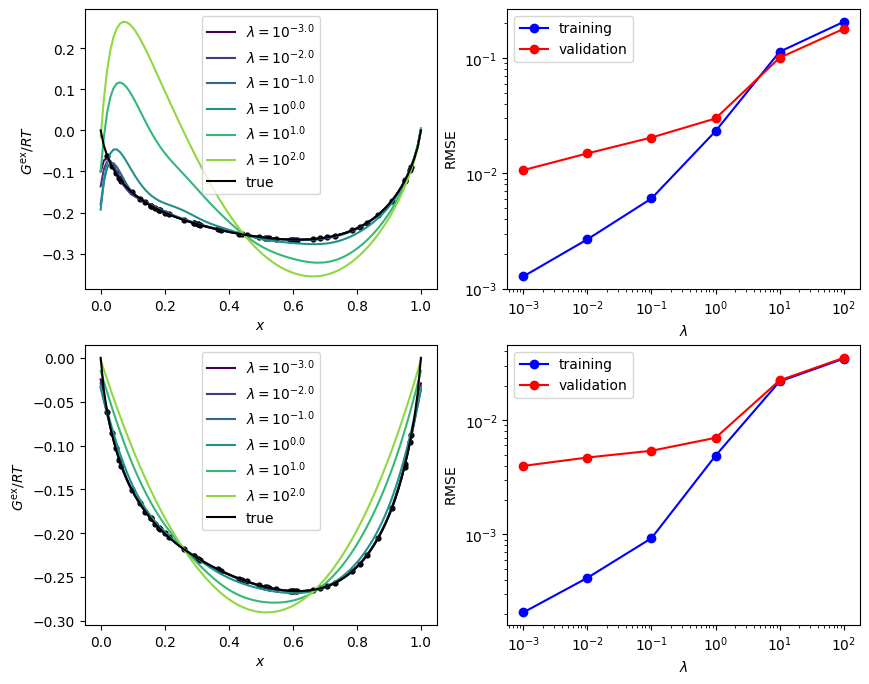

In [8]:
eta_sample = g_sample - np.array([nominal_model(x, P=760) for x in x_sample])
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 8))

# Method 1: Using the LS-based nominal model
alpha_range = np.logspace(-3, 2, 6)
rmse_train_range = []
rmse_val_range = []
cm = plt.get_cmap('viridis')
for k in range(len(alpha_range)):
    alpha = alpha_range[k]
    krr = KernelRidge(kernel='rbf', alpha=alpha, gamma=100) 
    krr.fit(x_sample.reshape(-1, 1), eta_sample)
    eta_predict = krr.predict(x_sample.reshape(-1, 1))
    rmse_train = np.sqrt(np.mean((eta_predict - eta_sample)**2))
    rmse_train_range.append(rmse_train)
    eta_predict = krr.predict(x_test.reshape(-1, 1))
    eta_true = np.array([excess_gibbs_energy(x) - nominal_model(x) for x in x_test])  
    rmse_val = np.sqrt(np.mean((eta_predict - eta_true)**2))
    rmse_val_range.append(rmse_val)
    print(f"RMSE_val: {rmse_val:.4f}, RMSE_train: {rmse_train:.4f}, alpha: {alpha:.1e}")
    ax1.plot(x_test, eta_predict + np.array([nominal_model(x, P=760) for x in x_test]), color=cm(k/len(alpha_range)), 
             label=r'$\lambda=10^{' + f'{np.log10(alpha):.1f}' + r'}$')
ax1.set_xlabel(r'$x$'), ax1.set_ylabel(r'$G^{\mathrm{ex}}/RT$')
ax1.scatter(x_sample, g_sample, marker='o', c='k', s=12)
ax1.plot(x_test, eta_true + np.array([nominal_model(x, P=760) for x in x_test]), color='k', label='true')
ax1.legend()
ax2.loglog(alpha_range, rmse_train_range, color='blue', marker='o', markerfacecolor='blue', label='training')
ax2.loglog(alpha_range, rmse_val_range, color='red', marker='o', markerfacecolor='red', label='validation')
ax2.set_xlabel(r'$\lambda$'), ax2.set_ylabel(r'$\mathrm{RMSE}$')
ax2.legend()

# Method 2: Using the Margules model as the interpretable subspace, performing parameter estimation along with KRR
alpha_range = np.logspace(-3, 2, 6)
rmse_train_range = []
rmse_val_range = []
cm = plt.get_cmap('viridis')
# kernel matrix 
G = np.array([[np.exp(-100*(x1-x2)**2) for x2 in x_sample] for x1 in x_sample])
Phi = np.vstack((x_sample**2*(1-x_sample), (1-x_sample)**2*x_sample)).T
M0 = np.vstack((Phi.T, G.T))
M1 = M0 @ M0.T
for k in range(len(alpha_range)):
    alpha = alpha_range[k]
    M1_reg = M1 + 0.0
    M1_reg[2:, 2:] += alpha*G
    coefs = np.linalg.solve(M1_reg, M0 @ g_sample)
    theta, c = coefs[:2], coefs[2:]
    predict_model = lambda x: Margules_model(x, theta) + sum( [c[i]*np.exp(-100*(x-x_sample[i])**2) for i in range(len(x_sample))] )
    g_predict = np.array([predict_model(x) for x in x_sample])
    rmse_train = np.sqrt(np.mean((g_predict - g_sample)**2))
    rmse_train_range.append(rmse_train)
    g_predict = np.array([predict_model(x) for x in x_test])
    rmse_val = np.sqrt(np.mean((g_predict - g_true)**2))
    rmse_val_range.append(rmse_val)
    print(f"RMSE_val: {rmse_val:.4f}, RMSE_train: {rmse_train:.4f}, alpha: {alpha:.1e}")
    ax3.plot(x_test, g_predict, color=cm(k/len(alpha_range)), 
             label=r'$\lambda=10^{' + f'{np.log10(alpha):.1f}' + r'}$')
ax3.set_xlabel(r'$x$'), ax3.set_ylabel(r'$G^{\mathrm{ex}}/RT$')
ax3.scatter(x_sample, g_sample, marker='o', c='k', s=12)
ax3.plot(x_test, g_true, color='k', label='true')
ax3.legend()
ax4.loglog(alpha_range, rmse_train_range, color='blue', marker='o', markerfacecolor='blue', label='training')
ax4.loglog(alpha_range, rmse_val_range, color='red', marker='o', markerfacecolor='red', label='validation')
ax4.set_xlabel(r'$\lambda$'), ax4.set_ylabel(r'$\mathrm{RMSE}$')
ax4.legend()

plt.show()

RMSE_val: 0.0047, RMSE_train: 0.0003, alpha: 1.0e-03
RMSE_val: 0.0060, RMSE_train: 0.0007, alpha: 1.0e-02
RMSE_val: 0.0080, RMSE_train: 0.0027, alpha: 1.0e-01
RMSE_val: 0.0238, RMSE_train: 0.0203, alpha: 1.0e+00
RMSE_val: 0.1033, RMSE_train: 0.0984, alpha: 1.0e+01
RMSE_val: 0.1709, RMSE_train: 0.1682, alpha: 1.0e+02
RMSE_val: 0.0047, RMSE_train: 0.0003, alpha: 1.0e-03
RMSE_val: 0.0060, RMSE_train: 0.0007, alpha: 1.0e-02
RMSE_val: 0.0080, RMSE_train: 0.0027, alpha: 1.0e-01
RMSE_val: 0.0238, RMSE_train: 0.0203, alpha: 1.0e+00
RMSE_val: 0.1033, RMSE_train: 0.0984, alpha: 1.0e+01
RMSE_val: 0.1709, RMSE_train: 0.1682, alpha: 1.0e+02
RMSE_val: 0.0047, RMSE_train: 0.0003, alpha: 1.0e-03
RMSE_val: 0.0060, RMSE_train: 0.0007, alpha: 1.0e-02
RMSE_val: 0.0080, RMSE_train: 0.0027, alpha: 1.0e-01
RMSE_val: 0.0238, RMSE_train: 0.0202, alpha: 1.0e+00
RMSE_val: 0.1033, RMSE_train: 0.0984, alpha: 1.0e+01
RMSE_val: 0.1709, RMSE_train: 0.1682, alpha: 1.0e+02


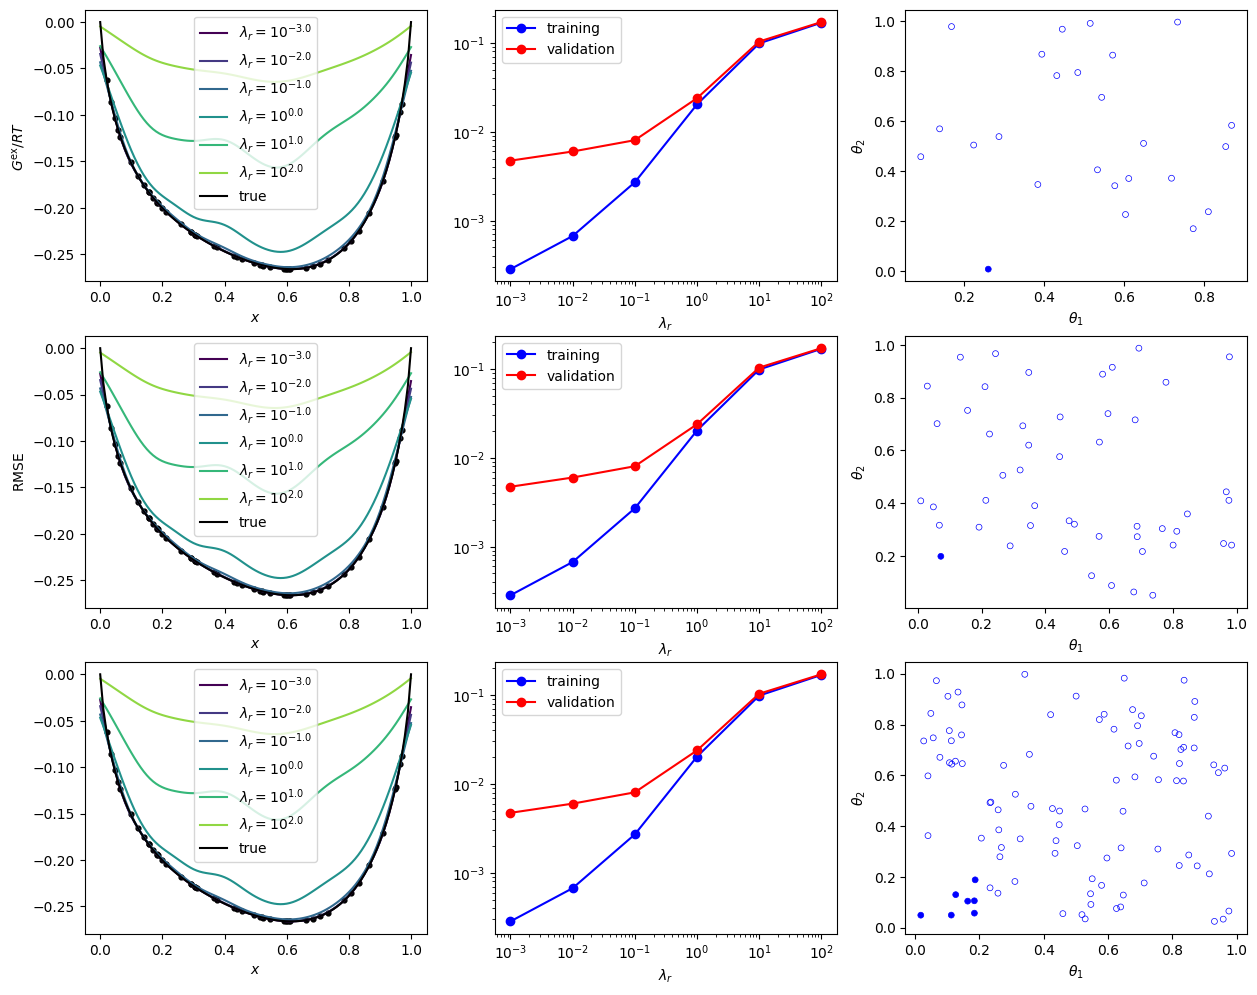

In [19]:
import cvxpy as cvx 
def Wilson_model(x, T, theta, P=760):
    A12, A21 = 10**(4*theta[0]-2), 10**(4*theta[1]-2)
    V1, V2, R = 58.7, 106.8, 8.314
    L12, L21 = V2/V1*np.exp(-A12/R/(T+273.15)), V1/V2*np.exp(-A21/R/(T+273.15))
    return -x*np.log(x+(1-x)*L12) - (1-x)*np.log((1-x)+x*L21)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
cm = plt.get_cmap('viridis')

m_range = [25, 50, 100]
for l in range(len(m_range)):
    m = m_range[l]
    thetas = np.random.random((m, 2)) 
    alpha_range, rmse_train_range, rmse_val_range = np.logspace(-3, 2, 6), [], []
    b_opt_range = []

    # Formulation of an optimization problem: min_{b, c} ||Hb+G_xc - g_sample||^2 + alpha*c^T*G_x*c, s.t. b>=0, e'b = 1
    G_x = np.array([[np.exp(-100*(x1-x2)**2) for x2 in x_sample] for x1 in x_sample])
    G_x = (G_x + G_x.T)/2
    H = np.array([[Wilson_model(x_sample[i], T_sample[i], thetas[j]) for j in range(m)] for i in range(len(x_sample))])
    for k in range(len(alpha_range)):
        alpha = alpha_range[k]
        b, c = cvx.Variable(m, nonneg=True), cvx.Variable(len(x_sample))
        objective = cvx.Minimize( cvx.sum_squares(H @ b + G_x @ c - g_sample) + alpha*cvx.quad_form(c, cvx.psd_wrap(G_x)) ) 
        prob = cvx.Problem(objective, [ cvx.sum(b) == 1 ])
        prob.solve()
        b_opt, c_opt = b.value, c.value
        b_opt_range.append(b_opt)
        predict_model = lambda x, T: sum ( [b_opt[j]*Wilson_model(x, T, thetas[j]) for j in range(m)] ) + sum( [c_opt[i]*np.exp(-100*(x-x_sample[i])**2) for i in range(len(x_sample))] )
        g_predict = np.array([predict_model(x_sample[i], T_sample[i]) for i in range(len(x_sample))])
        rmse_train = np.sqrt(np.mean((g_predict - g_sample)**2))
        rmse_train_range.append(rmse_train)
        g_predict = np.array([predict_model(x, T) for x, T in zip(x_test, T_test)])
        rmse_val = np.sqrt(np.mean((g_predict - g_true)**2))
        rmse_val_range.append(rmse_val)
        print(f"RMSE_val: {rmse_val:.4f}, RMSE_train: {rmse_train:.4f}, alpha: {alpha:.1e}")
        axes[l, 0].plot(x_test, g_predict, color=cm(k/len(alpha_range)), 
                label=r'$\lambda_r=10^{' + f'{np.log10(alpha):.1f}' + r'}$')
    axes[l, 0].set_xlabel(r'$x$'), axes[0, 0].set_ylabel(r'$G^{\mathrm{ex}}/RT$')
    axes[l, 0].scatter(x_sample, g_sample, marker='o', c='k', s=12)
    axes[l, 0].plot(x_test, g_true, color='k', label='true')
    axes[l, 0].legend()
    axes[l, 1].loglog(alpha_range, rmse_train_range, color='blue', marker='o', markerfacecolor='blue', label='training')
    axes[l, 1].loglog(alpha_range, rmse_val_range, color='red', marker='o', markerfacecolor='red', label='validation')
    axes[l, 1].set_xlabel(r'$\lambda_r$'), axes[1, 0].set_ylabel(r'$\mathrm{RMSE}$')
    axes[l, 1].legend() 
    axes[l, 2].scatter(thetas[:, 0], thetas[:, 1], marker='o', linewidth=0.5, 
                       edgecolors='b', facecolors=[(0, 0, 1, np.real(b_opt_range[-2][k]>=1.0/m)) for k in range(m)], s=18)
    axes[l, 2].set_xlabel(r'$\theta_1$'), axes[l, 2].set_ylabel(r'$\theta_2$')

plt.show()